### **Lembar Kerja Praktikum:**
* Mata Kuliah :BDDM
* Pertemuan Ke : 22
* CPMK: Mahasiswa Mampu Menerapkan Metode Analisis Data (CPMK 21)
* Sub CPMK: Mahasiswa dapat menjelaskan konsep dasar dan cara kerja algoritma clustering (un-supervised learning) (SCPMK 1682111)
* Indikator Keberhasilan: Mahasiswa penyelesaian contoh kasus clustering dalam bahasa pemrograman

### **Identitas Praktikan:**
* Nama: Yezha Amanando Rifky Zafian
* Nim: 23.11.5629
* Kelas: IF05

### **Petunjuk Praktikum:**
* LINK DATASET: https://s.amikom.ac.id/DATASET-MALLCUSTOMER

### **K Means**
Metode K-means merupakan metode clustering yang paling sederhana dan umum. Hal ini dikarenakan K-means mempunyai kemampuan mengelompokkan data dalam jumlah yang cukup besar dengan waktu komputasi yang cepat dan efisien.

**Inertia** mengukur seberapa dekat data-data dalam satu cluster terhadap centroid-nya.


*   Semakin kecil nilai inertia → cluster semakin rapat dan homogen, cluster semakin baik
*   Semakin besar nilai inertia → cluster semakin menyebar & hasil cluster kurang baik




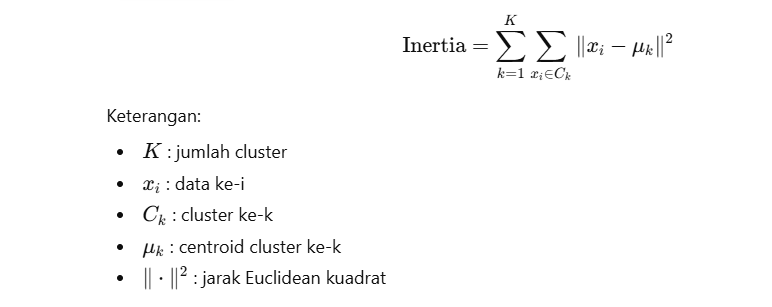

**WCSS (Within-Cluster Sum of Squares)** adalah ukuran kekompakan cluster pada algoritma clustering (terutama K-Means).
WCSS menghitung total jarak kuadrat antara setiap data dan centroid cluster tempat data tersebut berada.

**WCSS** mengukur seberapa rapat data di dalam masing-masing cluster.
Semakin kecil nilai WCSS → cluster semakin kompak.

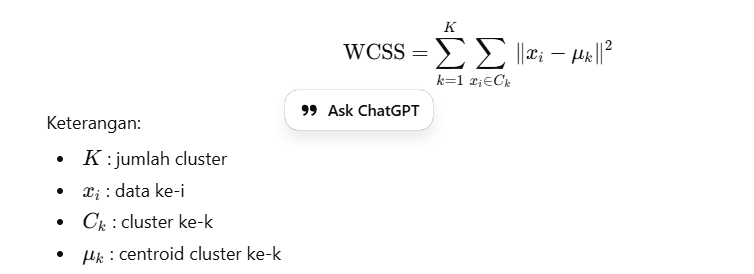

Elbow method: titik di mana penurunan WCSS mulai melambat(titik siku)

**Silhouette Score** adalah metrik evaluasi clustering yang mengukur seberapa baik setiap data ditempatkan di dalam cluster-nya dengan mempertimbangkan kekompakan (within-cluster) dan pemisahan (between-cluster).

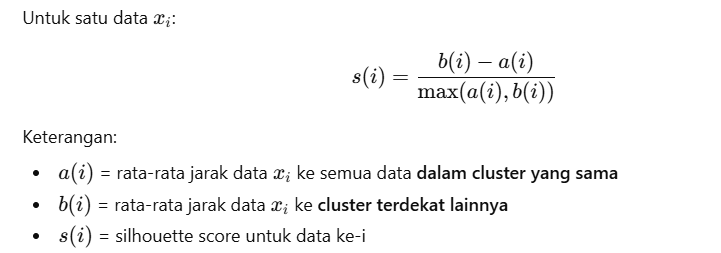

### **1. Import Library**



In [85]:
import numpy as np
import pandas as pd

# Visualization packages
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Determine number of clusters
from sklearn.metrics import silhouette_score

### **2. Load Dataset**

In [86]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [87]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### **3. Visualisasi Data**

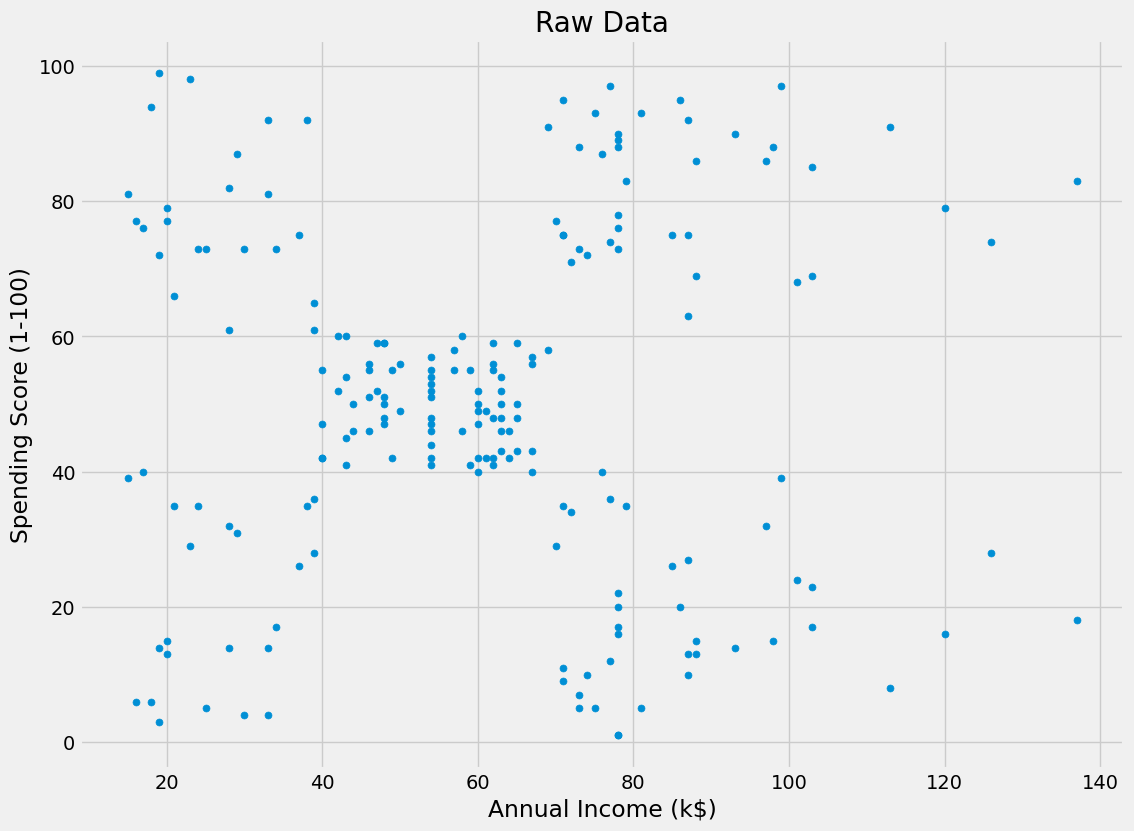

In [89]:
plt.figure(figsize=(12,9))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], s = 25) #Point size is 25
plt.title('Raw Data')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

### **4. Data Preprocessing**

feature selection

In [90]:
X = np.array(df.iloc[:,[3,4]])

In [91]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

### **5. Create Cluster**

In [92]:
kmeans = KMeans(n_clusters = 5, max_iter = 500, n_init = 10, random_state = 0)
kmeans_preds = kmeans.fit_predict(X)

In [93]:
#predict result
kmeans_preds

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [94]:
# Menampilkan pusat cluster
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [88.2        17.11428571]
 [26.30434783 20.91304348]
 [25.72727273 79.36363636]]


In [95]:
print("Inertia:", kmeans.inertia_)

Inertia: 44448.45544793369


### K-Mens_1 n_init 1

In [131]:
kmeans1 = KMeans(n_clusters = 5, max_iter = 500, n_init = 1, random_state = 0)
kmeans_preds1 = kmeans1.fit_predict(X)

In [132]:
#predict result
kmeans_preds1

array([2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 4, 4, 4, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 0, 4, 0, 0, 0, 4,
       4, 0, 4, 4, 0, 0, 0, 0, 0, 4, 4, 4, 4, 0, 0, 4, 0, 4, 4, 4, 4, 4,
       4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 0, 4, 0, 0,
       0, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 1, 4, 1, 4, 1, 3, 1, 3, 1,
       4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [133]:
# Menampilkan pusat cluster
print(kmeans1.cluster_centers_)

[[54.06       40.46       36.72      ]
 [32.69230769 86.53846154 82.12820513]
 [25.25       25.83333333 76.91666667]
 [41.64705882 88.73529412 16.76470588]
 [33.39622642 58.05660377 48.77358491]]


In [134]:
print("Inertia1:", kmeans1.inertia_)

Inertia1: 82608.63809385581


### K-Mens_20 n_init 20

In [135]:
kmeans20 = KMeans(n_clusters = 5, max_iter = 500, n_init = 20, random_state = 0)
kmeans_preds20 = kmeans20.fit_predict(X)

In [136]:
#predict result
kmeans_preds20

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 4, 1, 2, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

In [137]:
# Menampilkan pusat cluster
print(kmeans20.cluster_centers_)

[[45.2173913  26.30434783 20.91304348]
 [32.69230769 86.53846154 82.12820513]
 [43.08860759 55.29113924 49.56962025]
 [25.52173913 26.30434783 78.56521739]
 [40.66666667 87.75       17.58333333]]


In [138]:
print("Inertia20:", kmeans20.inertia_)

Inertia20: 75350.77917248776


### K-Mens_5 n_init 5

In [139]:
kmeans5 = KMeans(n_clusters = 5, max_iter = 500, n_init = 5, random_state = 0)
kmeans_preds5 = kmeans5.fit_predict(X)

In [140]:
#predict result
kmeans_preds5

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 4, 1, 2, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

In [141]:
# Menampilkan pusat cluster
print(kmeans5.cluster_centers_)

[[45.2173913  26.30434783 20.91304348]
 [32.69230769 86.53846154 82.12820513]
 [43.08860759 55.29113924 49.56962025]
 [25.52173913 26.30434783 78.56521739]
 [40.66666667 87.75       17.58333333]]


In [142]:
print("Inertia5:", kmeans5.inertia_)

Inertia5: 75350.77917248776


### ANALISIS:

Perbedaan hasil K-Means terjadi karena perbedaan jumlah inisialisasi centroid (n_init). Pada n_init = 1, model hanya melakukan satu percobaan sehingga berpotensi terjebak pada solusi lokal dengan inertia lebih besar. Sementara itu, pada n_init = 5 dan n_init = 20, model melakukan beberapa percobaan dan memilih hasil terbaik, sehingga menghasilkan inertia lebih kecil dan pusat cluster yang lebih stabil. Hal ini menunjukkan bahwa peningkatan n_init meningkatkan kualitas clustering hingga mencapai solusi optimal.

### K-Mens 2 Max iterasi 2

In [108]:
kmeans2 = KMeans(n_clusters = 5, max_iter = 2, n_init = 10, random_state = 0)
kmeans_preds2 = kmeans2.fit_predict(X)

In [109]:
#predict result
kmeans_preds2

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0, 0,
       4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [110]:
# Menampilkan pusat cluster
print(kmeans2.cluster_centers_)

[[54.68292683 49.36585366]
 [86.53846154 82.12820513]
 [87.75       17.58333333]
 [25.72727273 79.36363636]
 [25.14285714 19.52380952]]


In [111]:
print("Inertia2:", kmeans2.inertia_)

Inertia2: 44513.71663429531


### K-Mens 100  Max iterasi 100

In [143]:
kmeans100 = KMeans(n_clusters = 5, max_iter = 100, n_init = 10, random_state = 0)
kmeans_preds100 = kmeans100.fit_predict(X)

In [144]:
#predict result
kmeans_preds100

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 4, 1, 2, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

In [145]:
# Menampilkan pusat cluster
print(kmeans100.cluster_centers_)

[[45.2173913  26.30434783 20.91304348]
 [32.69230769 86.53846154 82.12820513]
 [43.08860759 55.29113924 49.56962025]
 [25.52173913 26.30434783 78.56521739]
 [40.66666667 87.75       17.58333333]]


In [146]:
print("Inertia100:", kmeans100.inertia_)

Inertia100: 75350.77917248776


### K-Mens 50 Max iterasi 50

In [147]:
kmeans50 = KMeans(n_clusters = 5, max_iter = 50, n_init = 10, random_state = 0)
kmeans_preds50 = kmeans50.fit_predict(X)

In [148]:
#predict result
kmeans_preds50

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 4, 1, 2, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

In [149]:
# Menampilkan pusat cluster
print(kmeans50.cluster_centers_)

[[45.2173913  26.30434783 20.91304348]
 [32.69230769 86.53846154 82.12820513]
 [43.08860759 55.29113924 49.56962025]
 [25.52173913 26.30434783 78.56521739]
 [40.66666667 87.75       17.58333333]]


In [150]:
print("Inertia50:", kmeans50.inertia_)

Inertia50: 75350.77917248776


### ANALISIS


Hasil pada percobaan K-Mens 2 ada perubahan itu karena hasil belum konvergen


### **6. Visualisasi Hasil Cluster**

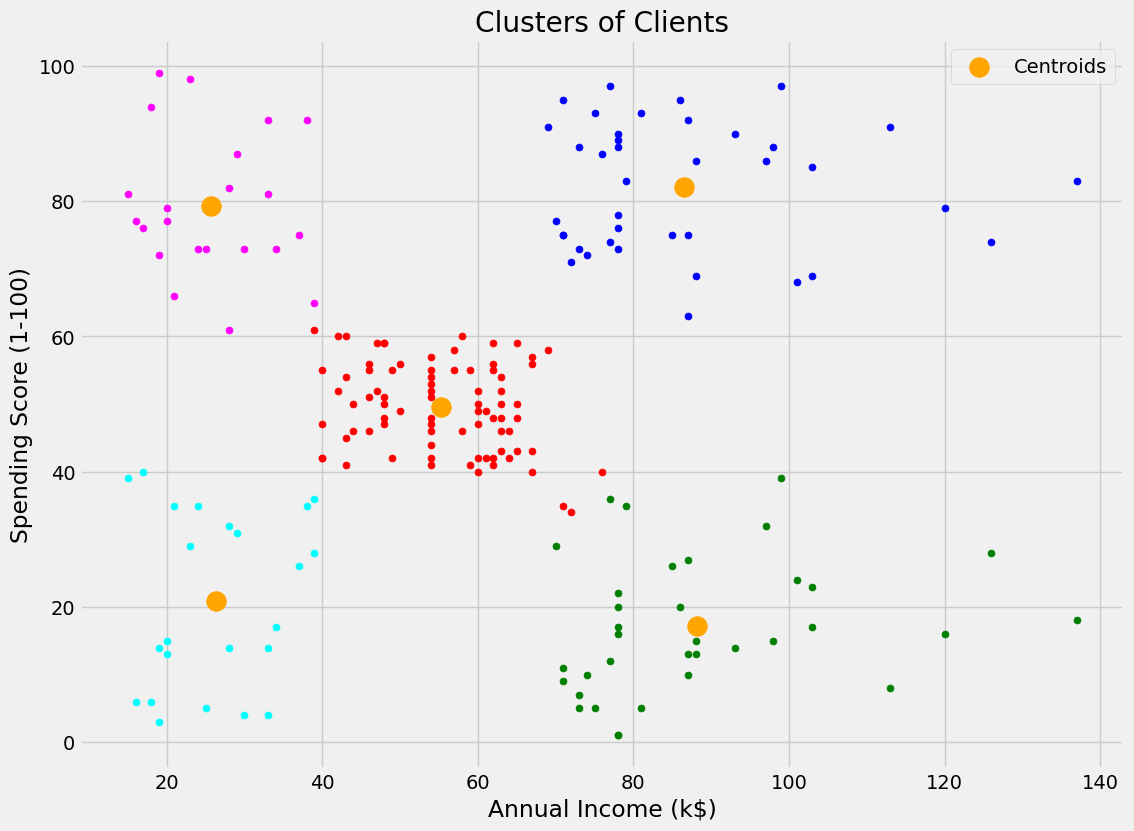

In [112]:
point_size = 25
colors = ['red', 'blue', 'green', 'cyan', 'magenta']


plt.figure(figsize = (12,9))
for i in range(5):
    plt.scatter(X[kmeans_preds == i,0], X[kmeans_preds == i,1], s = point_size,
                c = colors[i], )

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s = 200,
            c = 'orange', label = 'Centroids')
plt.title('Clusters of Clients')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc = 'best')
plt.show()

**Analisis:**


Hasil analisis clustering pada gambar tersebut sudah sangat bagus dan optimal. Kelima klaster terpisah dengan jelas tanpa ada tumpang tindih yang signifikan, dan titik Centroid warna oranye berada tepat di tengah-tengah konsentrasi data masing-masing kelompok. Hal ini menunjukkan bahwa algoritma kemungkinan K-Means berhasil mengidentifikasi lima segmen pelanggan yang berbeda berdasarkan pendapatan dan skor pengeluaran dengan tingkat kepadatan yang baik.

In [113]:
#menambahkan hasil clustering ke dalam dataframe
df['Cluster'] = kmeans_preds
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


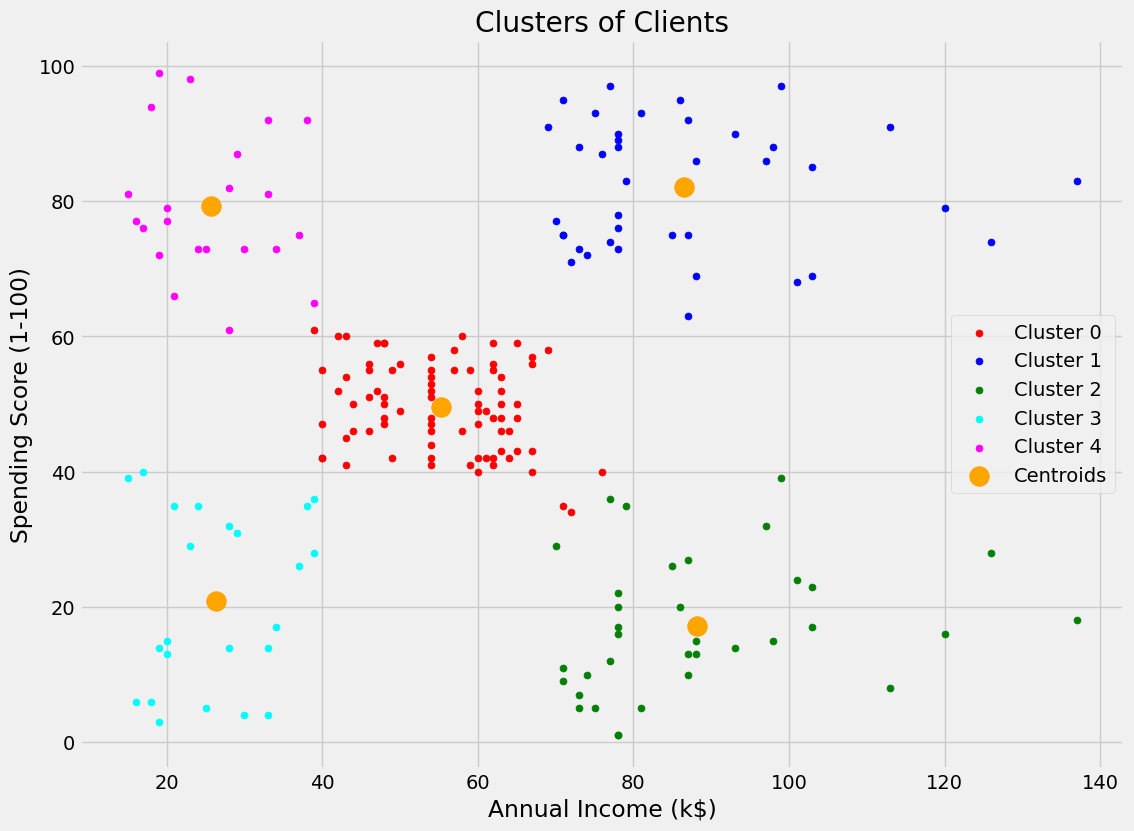

In [114]:
point_size = 25
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
cluster_names = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
    4: 'Cluster 4'
}

plt.figure(figsize = (12,9))
for i in range(5):
    plt.scatter(X[kmeans_preds == i,0], X[kmeans_preds == i,1], s = point_size,
                c = colors[i], label=cluster_names.get(i, f'Cluster {i}') )

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s = 200,
            c = 'orange', label = 'Centroids')
plt.title('Clusters of Clients')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc = 'best')
plt.show()

In [115]:
df.groupby(['Cluster'])['Cluster'].count()

,Cluster
Cluster,
0,81
1,39
2,35
3,23
4,22


In [116]:
#menampilkan cluster tertentu
data_cluster1=df.loc[df['Cluster'] == 1]

In [117]:
data_cluster1

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
123,124,Male,39,69,91,1
125,126,Female,31,70,77,1
127,128,Male,40,71,95,1
129,130,Male,38,71,75,1
131,132,Male,39,71,75,1
133,134,Female,31,72,71,1
135,136,Female,29,73,88,1
137,138,Male,32,73,73,1
139,140,Female,35,74,72,1
141,142,Male,32,75,93,1


### **Menentukan Jumlah Cluster Optimal**

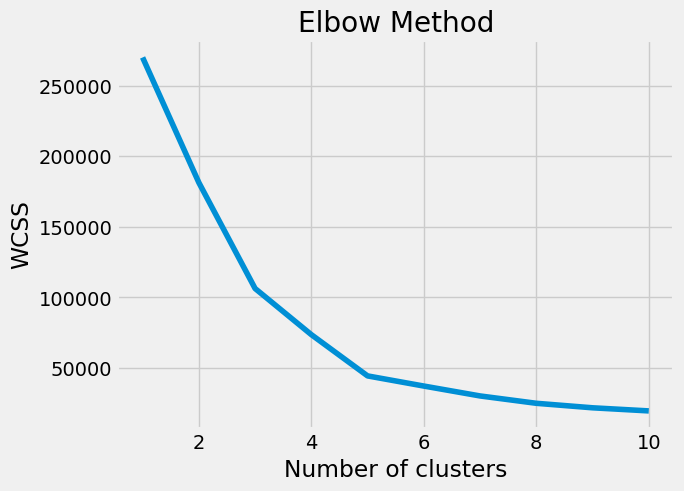

In [118]:
#Method 1 - Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [119]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_coefficients.append(score)

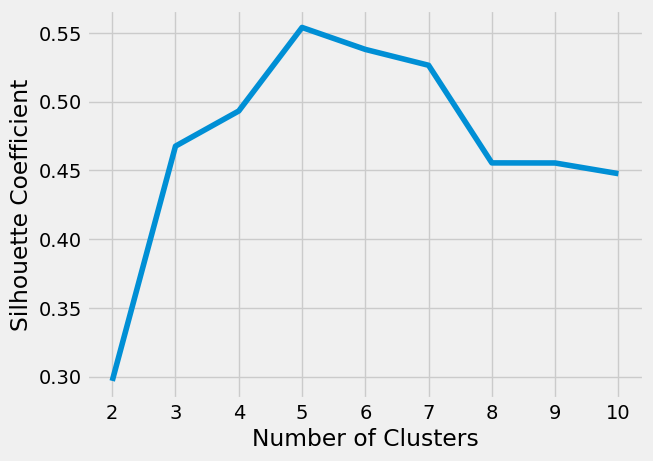

In [120]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

### **Clustering Multi Fitur**

In [121]:
import plotly as py
import plotly.graph_objs as go

In [122]:
X = np.array(df.iloc[:,[2,3,4]])

In [123]:
X[:5]

array([[19, 15, 39],
       [21, 15, 81],
       [20, 16,  6],
       [23, 16, 77],
       [31, 17, 40]])

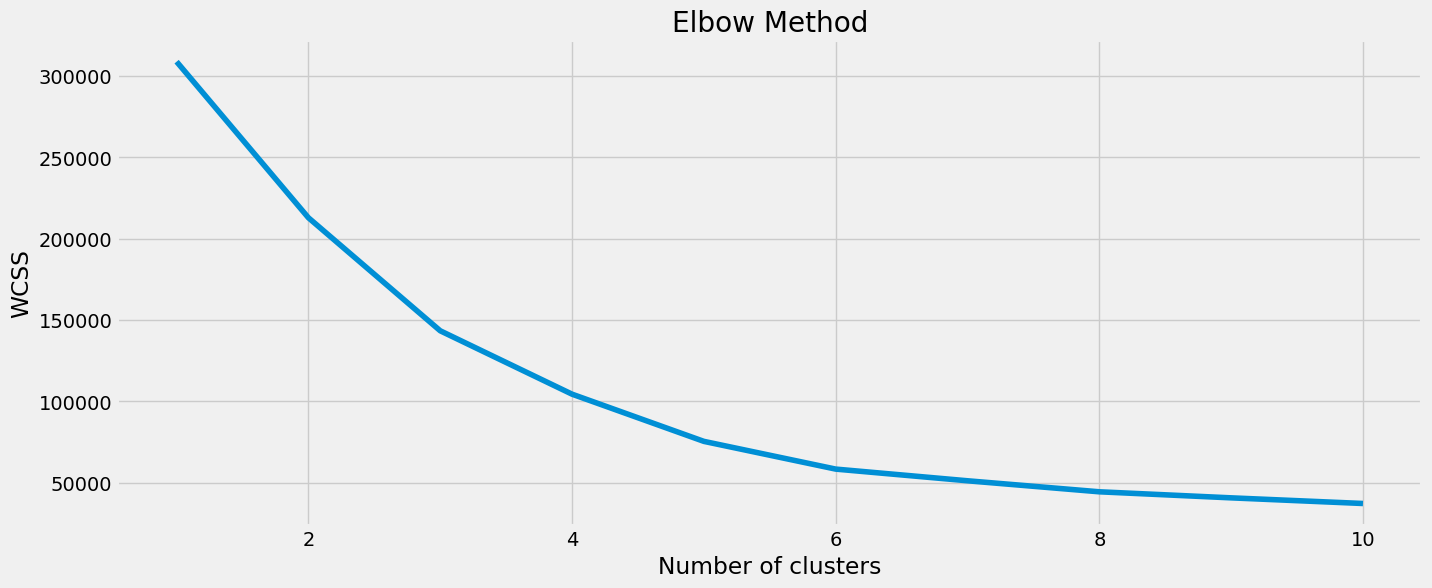

In [124]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.figure(1 , figsize = (15 ,6))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [125]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_coefficients.append(score)

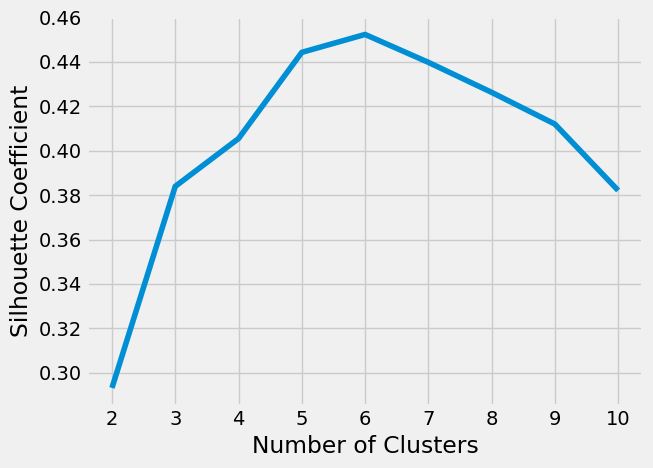

In [126]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

**Create Cluster**

In [127]:
kmeans = KMeans(n_clusters = 6, max_iter = 500, n_init = 10, random_state = 0)
kmeans_preds = kmeans.fit_predict(X)

In [128]:
#predict result
kmeans_preds

array([4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5,
       4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 3, 5, 3, 0,
       4, 5, 3, 0, 0, 0, 3, 0, 0, 3, 3, 3, 3, 3, 0, 3, 3, 0, 3, 3, 3, 0,
       3, 3, 0, 0, 3, 3, 3, 3, 3, 0, 3, 0, 0, 3, 3, 0, 3, 3, 0, 3, 3, 0,
       0, 3, 3, 0, 3, 0, 0, 0, 3, 0, 3, 0, 0, 3, 3, 0, 3, 0, 3, 3, 3, 3,
       3, 0, 0, 0, 0, 0, 3, 3, 3, 3, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [129]:
# Menampilkan pusat cluster
print(kmeans.cluster_centers_)

[[27.         56.65789474 49.13157895]
 [41.68571429 88.22857143 17.28571429]
 [32.69230769 86.53846154 82.12820513]
 [56.15555556 53.37777778 49.08888889]
 [44.14285714 25.14285714 19.52380952]
 [25.27272727 25.72727273 79.36363636]]


In [130]:
import plotly.graph_objs as go
import plotly.offline as py

# =========================
# Ambil label & centroid
# =========================
labels3 = kmeans.labels_
centroids3 = kmeans.cluster_centers_

df['ClusterMultiFeatures'] = labels3

# =========================
# Trace data (titik cluster)
# =========================
trace_data = go.Scatter3d(
    x=df['Age'],
    y=df['Spending Score (1-100)'],
    z=df['Annual Income (k$)'],
    mode='markers',
    marker=dict(
        color=df['ClusterMultiFeatures'],
        size=8,
        colorscale='Viridis',
        opacity=0.7
    ),
    name='Data Points'
)

# =========================
# Trace centroid
# =========================
trace_centroid = go.Scatter3d(
    x=centroids3[:, 0],   # Age
    y=centroids3[:, 1],   # Spending Score
    z=centroids3[:, 2],   # Annual Income
    mode='markers+text',
    marker=dict(
        color='red',
        size=14,
        symbol='diamond'
    ),
    text=[f'C{i}' for i in range(len(centroids3))],
    textposition='top center',
    name='Centroids'
)

# =========================
# Layout
# =========================
layout = go.Layout(
    title='3D Visualization of K-Means Clustering with Centroids',
    scene=dict(
        xaxis=dict(title='Age'),
        yaxis=dict(title='Spending Score (1-100)'),
        zaxis=dict(title='Annual Income (k$)')
    ),
    legend=dict(x=0.02, y=0.98)
)

# =========================
# Render
# =========================
fig = go.Figure(data=[trace_data, trace_centroid], layout=layout)
py.iplot(fig)

In [151]:
#menambahkan hasil clustering ke dalam dataframe
df['Cluster'] = kmeans_preds
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,ClusterMultiFeatures
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,5,5
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,5,5
4,5,Female,31,17,40,4,4


In [152]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,ClusterMultiFeatures
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,5,5
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,5,5
4,5,Female,31,17,40,4,4
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,2,2
196,197,Female,45,126,28,1,1
197,198,Male,32,126,74,2,2
198,199,Male,32,137,18,1,1


In [153]:
df.to_csv('Data cluster final.csv',index=False)